Den här prototypen för en RAG-bot (Retrieval-Augmented Generation) baserad på kursplanen för matematik, hämtat via API från Skolverket. I en slutgiltig version, med alla ämnen  laddade, kan botten vara en assistent för både elever och lärare. 

## Elever

Boten skulle kunna användas av elever som vill ha en djupare förståelse för kursplanerna, t.ex. inför prov, upsatser eller andra examinationer. Chattbotten skulle kunna vara bidragande till att hålla kusplanen levande, istället för att begränsat till bara den där obligatoriska genomgången i början av en termin som man knappt förstod något av. Chattbotten skulle kunna hjälpa till att göra innehållet mer begripligt och tillgängligt för elever som, exempelvis utifrån ålder, inte har förutsättningar att ta sig an informationen på egen hand. Ett etiskt dilemma är att det mycket väl skulle kunna användas för att fuska mer effektivt - "skriv om min upsats så att den bättre matchar kursmålen", etc. Boten skulle behöva noga begränsas för att förhindra detta - men detta, i min erfarenhet, verkar vara svårt även för de stora företagen att implementera utan att det är relativt lätt att kringgå. 

## Lärare

För lärare finns inte samma risk för fusk. För lärare kan botten vara ett hjälpsamt verktyg för att vara säker på att man håller sig till kursplanera och täcker allt centralt innehåll. Boten skulle kunna hjälpa till med förslag om uppgifter eller för lektionsplanering. Med källhänvisningar kan pedagoger också försäkra sig om att informationen de tar del av stämmer. Med samtliga ämnen inladdade i modellen skulle det också finnas möjligheter för lärare att genomföra större projekt, där man har samverkan mellan ämnen och checkar av centralt innehåll i båda (eller fler?) kursplaner. Pedagoger, särskilt i högre åldrar, har ofta djup kunskap om sitt eget ämne, men begränsad kännedom om andra. En gemensam och lättillgänglig kunskapsbas skulle således kunna öppna dörrar för samverkan. 
Ett naturligt steg för breddning i användningsområde ser jag skulle vara att implementera att modellen också används för bedömning. Den har ju trots allt information om allt en elev ska bedömas på, och datorer är ju alltid opartiska, så bedömningen skulle definitivt alltid bli helt korrekt och objektiv! Eller inte. Här blir det snabbt risk för att felaktiga bedömningar görs i en "svart låda" där man inte kan se vad det är som faktiskt utvärderts, även när modellen ombeds motivera sina beslut. Enligt skollagen (3 kap 16§) ska betyg "beslutas av den eller de lärare som bedriver undervisningen vid den tidpunkt när betyg ska sättas", vilket begränsar detta något, men lämnar fortfarande dörren vidöppen för att ta emot "rekommendationer" av AI. Detta skulle i längden kunna leda till "slarv" i bedömningen av uppgifter, där pedagoger litar blint på den bedömning AI ger. Det skulle också kunna leda till att pedagoger inte granskade elevernas uppgifter på samma sätt, vilket innebär att de inte får kännedom om elevens faktiska kunskaper - något man skulle kunna argumentera faktiskt är hela poängen med alla bedömningar fram till gymnasiet. Läraren går då miste om en möjlighet till att anpassa sin undervisning, samt riskerar att missa elever i behov av särskilt stöd (något som måste uppmärksammas och utredas skyndsamt enligt skollagen).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from N4_retriever import SubjRetriever
from N5_generator import SubjGenerator


In [2]:
# Stänger av vissa varningar för att utskrifterna ska bli lite renare
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
# Samlar inställningar på ett ställe så de blir lätta att ändra
TOP_K = 3
MIN_SCORE = 0.45
PREVIEW_CONTEXTS = 2

In [4]:
# Initierar retriever
retriever = SubjRetriever()
print("Retriever laddad")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Retriever laddad


In [5]:
# Initierar generator
generator = SubjGenerator()
print("Generator laddad")

Generator laddad


In [6]:
# Här skapar jag ett litet testset med frågor från olika typer av innehåll.
# Tanken är att inte bara testa en enda sorts fråga, utan lite blandat.

evaluation_questions = [
    {
        "id": 0,
        "kategori": "syfte",
        "fråga": "vad är syftet med matematikundervisning?",
    },
    {
        "id": 1,
        "kategori": "centralt innehåll",
        "fråga": "ska jag jobba med algebra i årskurs 4-6?",
    },
    {
        "id": 2,
        "kategori": "specifik fråga kunskapskrav",
        "fråga": "kunskapskrav geometri årskurs 6?",
    },
    {
        "id": 3,
        "kategori": "gränsfall",
        "fråga": "vad säger kursplanen om programmering i matematik?",
    },
    {
        "id": 4,
        "kategori": "fråga som det inte ska finnas svar på",
        "fråga": "vart ligger atlantis?",
    }
]

questions_df = pd.DataFrame(evaluation_questions)
questions_df

,id,kategori,fråga
0,0,syfte,vad är syftet med matematikundervisning?
1,1,centralt innehåll,ska jag jobba med algebra i årskurs 4-6?
2,2,specifik fråga kunskapskrav,kunskapskrav geometri årskurs 6?
3,3,gränsfall,vad säger kursplanen om programmering i matema...
4,4,fråga som det inte ska finnas svar på,vart ligger atlantis?


In [ ]:
# Funktion som kör en fråga genom hela pipelinen
def run_single_evaluation(item, retriever, generator, top_k=3, min_score=0.45, preview_contexts=2):
    query = item["fråga"]

    print(f"\nTEST {item['id'] + 1}: '{query}'")

    # Hämtar retrieval-resultatet som en dictionary
    retrieval_result = retriever.retrieve(query, k=top_k, min_score=min_score)

    # Plockar ut de delar vi vill använda vidare
    contexts = retrieval_result["contexts"]
    sources = retrieval_result["sources"]
    scores = retrieval_result["scores"]
    best_score = retrieval_result["best_score"]
    has_support = retrieval_result["has_support"]

    print("Retrieval klar")

    # Om stödet saknas behövs ingen generering
    if not has_support:
        answer = "Jag hittar inte detta i källmaterialet."
        print("Generering hoppades över")
    else:
        print("Försöker generera svar...")
        answer = generator.generate_response(query, retrieval_result)
        print("Generering klar")

    print(f"Best score: {best_score}")
    print(f"Has support: {has_support}")
    print(f"SVAR: {answer}")
    print("-" * 80)

    return {
        "id": item["id"],
        "kategori": item["kategori"],
        "fråga": query,
        "has_support": has_support,
        "best_score": best_score,
        "alla_scores": " | ".join([str(round(score, 4)) for score in scores]),
        "hämtade_källor": " | ".join(sources),
        "hämtad_kontext": " || ".join(contexts[:preview_contexts]),
        "modellens_svar": answer
    }

In [21]:
# Kör alla testfrågor genom hela pipelinen
results = []

print("\n" + "=" * 80)
print("EVALUERING: Kör testfrågor genom hela pipelinen")
print("=" * 80)

for item in evaluation_questions:
    result_row = run_single_evaluation(
        item,
        retriever=retriever,
        generator=generator,
        top_k=TOP_K,
        min_score=MIN_SCORE,
        preview_contexts=PREVIEW_CONTEXTS
    )
    results.append(result_row)

eval_df = pd.DataFrame(results)


Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



EVALUERING: Kör testfrågor genom hela pipelinen

TEST 1: 'vad är syftet med matematikundervisning?'
Retrieval klar
Försöker generera svar...


Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generering klar
Best score: 0.6132144331932068
Has support: True
SVAR: Syftet med matematikundervisningen är att ge eleverna de kunskaper och färdigheter som krävs för att kunna lösa problem inom olika områden av livet. Matematik används ofta i utbildningssammanhang för att förklara komplexa begrepp och lösa problem. Det kan också användas som ett verktyg för lärande och kommunikation mellan elever.
--------------------------------------------------------------------------------

TEST 2: 'ska jag jobba med algebra i årskurs 4-6?'
Retrieval klar
Försöker generera svar...


Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generering klar
Best score: 0.723490834236145
Has support: True
SVAR: Ja! Att arbeta med algebra kan vara ett bra sätt att lära sig grunderna i ämnet. Det ger dig möjlighet att utforska olika typer av problem och utveckla din förmåga att tänka logiskt och kreativt. Dessutom kommer du att få praktisk erfarenhet genom att använda matematikverktyg som matriser, vektorer och formler.
--------------------------------------------------------------------------------

TEST 3: 'kunskapskrav geometri årskurs 6?'
Retrieval klar
Försöker generera svar...


Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generering klar
Best score: 0.8649435043334961
Has support: True
SVAR: Ja! Här följer ett exempel på hur du kan ställa frågor till Skolverket angående kunskapskraven i geometri för årskursen 6:

Vad innebär geometrisk form i geometrin?
Vilka typer av former finns det?
Hur påverkas geometriska former av olika material?
Vilken betydelse har geometrikens egenskaper såsom volym, area och längd i geometrien?
--------------------------------------------------------------------------------

TEST 4: 'vad säger kursplanen om programmering i matematik?'
Retrieval klar
Försöker generera svar...
Generering klar
Best score: 0.71863853931427
Has support: True
SVAR: I kursplanen för matematik finns det information om programmering inom olika områden såsom datavetenskap, teknik, naturvetenskap och samhällsvetenskap. I kursplanen ingår även ett avsnitt om programmeringsspråket C++.
--------------------------------------------------------------------------------

TEST 5: 'vart ligger atlantis?'
Retrieva

In [22]:
# Skriver ut bred PD för bättre översikt
pd.set_option("display.max_colwidth", None)
eval_df

,id,kategori,fråga,has_support,best_score,alla_scores,hämtade_källor,hämtad_kontext,modellens_svar
0,0,syfte,vad är syftet med matematikundervisning?,True,0.613214,0.6132 | 0.5973 | 0.588,"GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 1-3, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall)","Formulering av matematiska frågeställningar utifrån vardagliga situatio­ner. || Metoder för beräkningar med naturliga tal, vid huvudräkning, över­slags­räkning och skriftlig beräkning. Användning av digitala verktyg vid be­räk­ningar.",Syftet med matematikundervisningen är att ge eleverna de kunskaper och färdigheter som krävs för att kunna lösa problem inom olika områden av livet. Matematik används ofta i utbildningssammanhang för att förklara komplexa begrepp och lösa problem. Det kan också användas som ett verktyg för lärande och kommunikation mellan elever.
1,1,centralt innehåll,ska jag jobba med algebra i årskurs 4-6?,True,0.723491,0.7235 | 0.6797 | 0.6772,"GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 7-9, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 6, Sektion: kunskapskrav)",Algebra för årskurs 4-6. Variabler och deras användning i enkla algebraiska uttryck och ekvationer. || Algebra för årskurs 7-9. Metoder för att lösa linjära ekvationer och enkla andragradsekvationer.,"Ja! Att arbeta med algebra kan vara ett bra sätt att lära sig grunderna i ämnet. Det ger dig möjlighet att utforska olika typer av problem och utveckla din förmåga att tänka logiskt och kreativt. Dessutom kommer du att få praktisk erfarenhet genom att använda matematikverktyg som matriser, vektorer och formler."
2,2,specifik fråga kunskapskrav,kunskapskrav geometri årskurs 6?,True,0.864944,0.8649 | 0.8515 | 0.6983,"GRGRMAT01 v14 (Årskurs: 6, Sektion: kunskapskrav) | GRGRMAT01 v14 (Årskurs: 6, Sektion: kunskapskrav) | GRGRMAT01 v14 (Årskurs: 1-3, Sektion: centralt_innehall)","Kunskapskrav för årskurs 6. Eleven visar goda kunskaper om matematiska begrepp samt använder och beskriver begrepp och samband mellan begrepp inom områdena taluppfattning och tals användning, algebra, geometri, sannolikhet och statistik samt samband och förändring med god säkerhet. || Kunskapskrav för årskurs 6. Eleven väljer och använder ändamålsenliga matematiska metoder för att göra beräkningar och lösa rutinuppgifter inom områdena taluppfattning och tals användning, algebra, geometri, sannolikhet och statistik samt samband och förändring med god säkerhet.","Ja! Här följer ett exempel på hur du kan ställa frågor till Skolverket angående kunskapskraven i geometri för årskursen 6:\n\nVad innebär geometrisk form i geometrin?\nVilka typer av former finns det?\nHur påverkas geometriska former av olika material?\nVilken betydelse har geometrikens egenskaper såsom volym, area och längd i geometrien?"
3,3,gränsfall,vad säger kursplanen om programmering i matematik?,True,0.718639,0.7186 | 0.6606 | 0.5994,"GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 7-9, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 1-3, Sektion: centralt_innehall)","Programmering i visuella programmeringsmiljöer. Hur algoritmer ska­pas och används vid programmering. || Programmering i visuell och textbaserad programmeringsmiljö. Hur algo­rit­mer skapas, testas och förbättras vid programmering.","I kursplanen för matematik finns det information om programmering inom olika områden såsom datavetenskap, teknik, naturvetenskap och samhällsvetenskap. I kursplanen ingår även ett avsnitt om programmeringsspråket C++."
4,4,fråga som det inte ska finnas svar på,vart ligger atlantis?,False,0.343044,0.343 | 0.3364 | 0.3135,,,Jag hittar inte detta i källmaterialet.


## Bedömningsguide för manuell evaluering av chattboten

Här bedömer jag varje svar med samma kriterier varje gång.
På så sätt blir evalueringen mer konsekvent och lättare att motivera.

Jag tittar på:
 1. Frågan
 2. Hämtade källor och kontext
 3. Modellens svar

 Sedan fyller jag i:
 - relevans - **Svarar modellen faktiskt på frågan jag ställde?**
 - källtrohet - **Går det modellen säger faktiskt att hitta i den hämtade kontexten?**
 - retrieval_träff - **Hämtade retrievern rätt slags information?**
 - tydlighet - **Är svaret begripligt och rimligt formulerat?**
 - hallucination - **Hittar modellen på något som inte finns i materialet?**
 - eventuell kommentar

För att göra bedömningen mer konsekvent/replikerbar väljer jag att göra en binär bedömning, dvs. har den, eller har den inte, klarat att svara enligt min förbestämda fråga? Har den klarat av kriteriet så får den poäng **1** och annars **0**. Med denna typ av bedömning kan det vara svårare att upptäcka t.ex. om jag förbättrar min modell mellan iterationer, men har som sagt fördelen att bli mindre subjektiv än en mer nyanserad skala där det t.ex. kan bli svårt att avgöra skillnaden mellan ett "ok" svar och ett "bra" svar.  

In [10]:
# Skriver ut frågorna en efter en för enklare översikt
eval_df.iloc[[4]]

,id,kategori,fråga,has_support,best_score,alla_scores,hämtade_källor,hämtad_kontext,modellens_svar
4,4,fråga som det inte ska finnas svar på,vart ligger atlantis?,False,0.343044,0.343 | 0.3364 | 0.3135,,,Jag hittar inte detta i källmaterialet.


In [11]:
# Här lägger jag den manuella bedömningen i en separat struktur.
# Det gör det lättare att ändra eller lägga till fler frågor senare.

manual_assessment = [
    {
        "id": 0,
        "relevans_0_1": 1,
        "källtrohet_0_1": 1,
        "retrieval_träff_0_1": 1,
        "tydlighet_0_1": 1,
        "hallucination_0_1": 0,
        "kommentar": "Bra svar men är i fel sektion och kikar - den är i centralt innehåll, inte i syfte."
    },
    {
        "id": 1,
        "relevans_0_1": 1,
        "källtrohet_0_1": 1,
        "retrieval_träff_0_1": 1,
        "tydlighet_0_1": 1,
        "hallucination_0_1": 0,
        "kommentar": "Lite väl utförligt förklarat om varför, kanske, istället för bara ja eller nej."
    },
    {
        "id": 2,
        "relevans_0_1": 1,
        "källtrohet_0_1": 1, 
        "retrieval_träff_0_1": 1, # två av tre gäller åk 6, den sista åk 3... får godkänt för att det ändå är 2/3 rätt plus att den för 1-3 också har mycket lägre score
        "tydlighet_0_1": 1,
        "hallucination_0_1": 0,
        "kommentar": "Lite konstigt med 'ställa frågor till skolverket' och det där som material, men punkterna i övrigt är relevanta. Bra med exempel på lite slarvigt formulerad fråga."
    },
    {
        "id": 3,
        "relevans_0_1": 1,
        "källtrohet_0_1": 0, # Står inget om naturkunskap eller samhällskunskap i kursplanen
        "retrieval_träff_0_1": 1, # Kontexten ser bra ut... funderar på om det i själva "tolkningen" av in-materialet som modellen rör ihop det? 
        "tydlighet_0_1": 1,
        "hallucination_0_1": 0, # Den har hittat på det där med C++, NO och SO, men känns lite mer som en "tolkningsfråga" än en hallucination...? 
        "kommentar": "Svår fråga att poängsätta. Jag kan ha varit lite för snäll."
    },
    {
        "id": 4,
        "relevans_0_1": 1,
        "källtrohet_0_1": 1,
        "retrieval_träff_0_1": 1,
        "tydlighet_0_1": 1,
        "hallucination_0_1": 0,
        "kommentar": "Helt korrekt hanterat!"
    }
]

manual_df = pd.DataFrame(manual_assessment)
manual_df

,id,relevans_0_1,källtrohet_0_1,retrieval_träff_0_1,tydlighet_0_1,hallucination_0_1,kommentar
0,0,1,1,1,1,0,"Bra svar men är i fel sektion och kikar - den är i centralt innehåll, inte i syfte."
1,1,1,1,1,1,0,"Lite väl utförligt förklarat om varför, kanske, istället för bara ja eller nej."
2,2,1,1,1,1,0,"Lite konstigt med 'ställa frågor till skolverket' och det där som material, men punkterna i övrigt är relevanta. Bra med exempel på lite slarvigt formulerad fråga."
3,3,1,0,1,1,0,Svår fråga att poängsätta. Jag kan ha varit lite för snäll.
4,4,1,1,1,1,0,Helt korrekt hanterat!


In [12]:
# Slår ihop pipeline-resultat och manuell bedömning i en gemensam tabell
eval_df = eval_df.merge(manual_df, on="id", how="left")
eval_df

,id,kategori,fråga,has_support,best_score,alla_scores,hämtade_källor,hämtad_kontext,modellens_svar,relevans_0_1,källtrohet_0_1,retrieval_träff_0_1,tydlighet_0_1,hallucination_0_1,kommentar
0,0,syfte,vad är syftet med matematikundervisning?,True,0.613214,0.6132 | 0.5973 | 0.588,"GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 1-3, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall)","Formulering av matematiska frågeställningar utifrån vardagliga situatio­ner. || Metoder för beräkningar med naturliga tal, vid huvudräkning, över­slags­räkning och skriftlig beräkning. Användning av digitala verktyg vid be­räk­ningar.",Syftet med matematikundervisningen är att ge eleverna de kunskaper och färdigheter som krävs för att kunna lösa problem inom olika områden av livet. Matematik används ofta i utbildningssammanhang för att förklara komplexa begrepp och lösa problem. Det kan också användas som ett verktyg för lärande och kommunikation mellan elever.,1,1,1,1,0,"Bra svar men är i fel sektion och kikar - den är i centralt innehåll, inte i syfte."
1,1,centralt innehåll,ska jag jobba med algebra i årskurs 4-6?,True,0.723491,0.7235 | 0.6797 | 0.6772,"GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 7-9, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 6, Sektion: kunskapskrav)",Algebra för årskurs 4-6. Variabler och deras användning i enkla algebraiska uttryck och ekvationer. || Algebra för årskurs 7-9. Metoder för att lösa linjära ekvationer och enkla andragradsekvationer.,"Ja! Att arbeta med algebra kan vara ett bra sätt att lära sig grunderna i ämnet. Det ger dig möjlighet att utforska olika typer av problem och utveckla din förmåga att tänka logiskt och kreativt. Dessutom kommer du att få praktisk erfarenhet genom att använda matematikverktyg som matriser, vektorer och formler.",1,1,1,1,0,"Lite väl utförligt förklarat om varför, kanske, istället för bara ja eller nej."
2,2,specifik fråga kunskapskrav,kunskapskrav geometri årskurs 6?,True,0.864944,0.8649 | 0.8515 | 0.6983,"GRGRMAT01 v14 (Årskurs: 6, Sektion: kunskapskrav) | GRGRMAT01 v14 (Årskurs: 6, Sektion: kunskapskrav) | GRGRMAT01 v14 (Årskurs: 1-3, Sektion: centralt_innehall)","Kunskapskrav för årskurs 6. Eleven visar goda kunskaper om matematiska begrepp samt använder och beskriver begrepp och samband mellan begrepp inom områdena taluppfattning och tals användning, algebra, geometri, sannolikhet och statistik samt samband och förändring med god säkerhet. || Kunskapskrav för årskurs 6. Eleven väljer och använder ändamålsenliga matematiska metoder för att göra beräkningar och lösa rutinuppgifter inom områdena taluppfattning och tals användning, algebra, geometri, sannolikhet och statistik samt samband och förändring med god säkerhet.","Ja! Här följer ett exempel på hur du kan ställa frågor till Skolverket angående kunskapskraven i geometri för årskursen 6:\n\nVad innebär geometrisk form i geometrin?\nVilka typer av former finns det?\nHur påverkas geometriska former av olika material?\nVilken betydelse har geometrikens egenskaper såsom volym, area och längd i geometrien?",1,1,1,1,0,"Lite konstigt med 'ställa frågor till skolverket' och det där som material, men punkterna i övrigt är relevanta. Bra med exempel på lite slarvigt formulerad fråga."
3,3,gränsfall,vad säger kursplanen om programmering i matematik?,True,0.718639,0.7186 | 0.6606 | 0.5994,"GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 7-9, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 1-3, Sektion: centralt_innehall)","Programmering i visuella programmeringsmiljöer. Hur algoritmer ska­pas och används vid programmering. || Programmering i visuell och textbaserad programmeringsmiljö. Hur algo­rit­mer skapas, testas och förbättras vid programmering.","I kursplanen för matematik finns det information om programmering inom olika områden såsom datavetenskap, teknik, naturvetenskap oc

In [13]:
# Gör om bedömningskolumner till numeriska värden
score_columns = [
    "relevans_0_1",
    "källtrohet_0_1",
    "retrieval_träff_0_1",
    "tydlighet_0_1",
    "hallucination_0_1"
]

scored_df = eval_df.copy()

for col in score_columns:
    scored_df[col] = pd.to_numeric(scored_df[col], errors="coerce")

In [14]:
# Räknar ut totalpoäng.
# Hallucination dras av eftersom 1 där betyder något dåligt.

scored_df["totalpoäng"] = (
    scored_df["relevans_0_1"].fillna(0)
    + scored_df["källtrohet_0_1"].fillna(0)
    + scored_df["retrieval_träff_0_1"].fillna(0)
    + scored_df["tydlighet_0_1"].fillna(0)
    - scored_df["hallucination_0_1"].fillna(0)
)

scored_df

,id,kategori,fråga,has_support,best_score,alla_scores,hämtade_källor,hämtad_kontext,modellens_svar,relevans_0_1,källtrohet_0_1,retrieval_träff_0_1,tydlighet_0_1,hallucination_0_1,kommentar,totalpoäng
0,0,syfte,vad är syftet med matematikundervisning?,True,0.613214,0.6132 | 0.5973 | 0.588,"GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 1-3, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall)","Formulering av matematiska frågeställningar utifrån vardagliga situatio­ner. || Metoder för beräkningar med naturliga tal, vid huvudräkning, över­slags­räkning och skriftlig beräkning. Användning av digitala verktyg vid be­räk­ningar.",Syftet med matematikundervisningen är att ge eleverna de kunskaper och färdigheter som krävs för att kunna lösa problem inom olika områden av livet. Matematik används ofta i utbildningssammanhang för att förklara komplexa begrepp och lösa problem. Det kan också användas som ett verktyg för lärande och kommunikation mellan elever.,1,1,1,1,0,"Bra svar men är i fel sektion och kikar - den är i centralt innehåll, inte i syfte.",4
1,1,centralt innehåll,ska jag jobba med algebra i årskurs 4-6?,True,0.723491,0.7235 | 0.6797 | 0.6772,"GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 7-9, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 6, Sektion: kunskapskrav)",Algebra för årskurs 4-6. Variabler och deras användning i enkla algebraiska uttryck och ekvationer. || Algebra för årskurs 7-9. Metoder för att lösa linjära ekvationer och enkla andragradsekvationer.,"Ja! Att arbeta med algebra kan vara ett bra sätt att lära sig grunderna i ämnet. Det ger dig möjlighet att utforska olika typer av problem och utveckla din förmåga att tänka logiskt och kreativt. Dessutom kommer du att få praktisk erfarenhet genom att använda matematikverktyg som matriser, vektorer och formler.",1,1,1,1,0,"Lite väl utförligt förklarat om varför, kanske, istället för bara ja eller nej.",4
2,2,specifik fråga kunskapskrav,kunskapskrav geometri årskurs 6?,True,0.864944,0.8649 | 0.8515 | 0.6983,"GRGRMAT01 v14 (Årskurs: 6, Sektion: kunskapskrav) | GRGRMAT01 v14 (Årskurs: 6, Sektion: kunskapskrav) | GRGRMAT01 v14 (Årskurs: 1-3, Sektion: centralt_innehall)","Kunskapskrav för årskurs 6. Eleven visar goda kunskaper om matematiska begrepp samt använder och beskriver begrepp och samband mellan begrepp inom områdena taluppfattning och tals användning, algebra, geometri, sannolikhet och statistik samt samband och förändring med god säkerhet. || Kunskapskrav för årskurs 6. Eleven väljer och använder ändamålsenliga matematiska metoder för att göra beräkningar och lösa rutinuppgifter inom områdena taluppfattning och tals användning, algebra, geometri, sannolikhet och statistik samt samband och förändring med god säkerhet.","Ja! Här följer ett exempel på hur du kan ställa frågor till Skolverket angående kunskapskraven i geometri för årskursen 6:\n\nVad innebär geometrisk form i geometrin?\nVilka typer av former finns det?\nHur påverkas geometriska former av olika material?\nVilken betydelse har geometrikens egenskaper såsom volym, area och längd i geometrien?",1,1,1,1,0,"Lite konstigt med 'ställa frågor till skolverket' och det där som material, men punkterna i övrigt är relevanta. Bra med exempel på lite slarvigt formulerad fråga.",4
3,3,gränsfall,vad säger kursplanen om programmering i matematik?,True,0.718639,0.7186 | 0.6606 | 0.5994,"GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 7-9, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 1-3, Sektion: centralt_innehall)","Programmering i visuella programmeringsmiljöer. Hur algoritmer ska­pas och används vid programmering. || Programmering i visuell och textbaserad programmeringsmiljö. Hur algo­rit­mer skapas, testas och förbättras vid programmering.","I kursplanen för matematik finns det information om programmering inom olika områden såsom datavetenskap, teknik, 

In [15]:
# Tabell för en snabb överblick över hur boten presterade totalt
summary_df = pd.DataFrame([{
    "antal_frågor": len(scored_df),
    "top_k": TOP_K,
    "min_score": MIN_SCORE,
    "medelpoäng": scored_df["totalpoäng"].mean(),
    "maxpoäng_per_fråga": 4,
    "medel_relevans": scored_df["relevans_0_1"].mean(),
    "medel_källtrohet": scored_df["källtrohet_0_1"].mean(),
    "medel_retrieval": scored_df["retrieval_träff_0_1"].mean(),
    "medel_tydlighet": scored_df["tydlighet_0_1"].mean(),
    "andel_hallucination": scored_df["hallucination_0_1"].mean()
}])

summary_df

,antal_frågor,top_k,min_score,medelpoäng,maxpoäng_per_fråga,medel_relevans,medel_källtrohet,medel_retrieval,medel_tydlighet,andel_hallucination
0,5,3,0.45,3.8,4,1.0,0.8,1.0,1.0,0.0


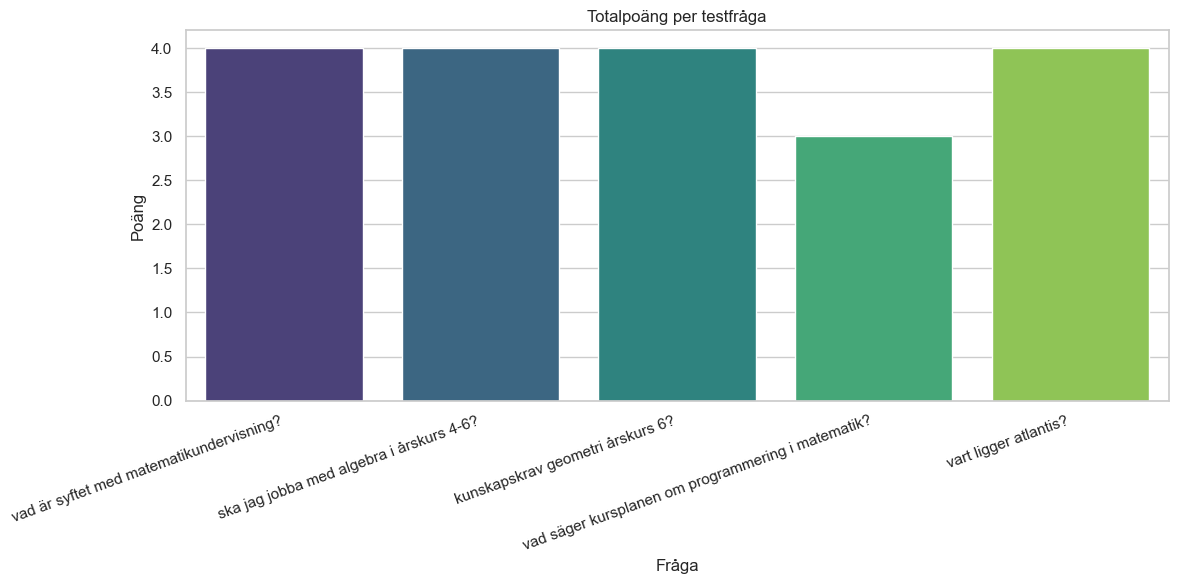

In [16]:
# Ett enkelt stapeldiagram över totalpoängen per fråga
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=scored_df,
    x="fråga",
    y="totalpoäng",
    hue="kategori",
    dodge=False,
    palette="viridis",
    legend=False
)

ax.set_title("Totalpoäng per testfråga")
ax.set_xlabel("Fråga")
ax.set_ylabel("Poäng")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [17]:
# Skapar en tabell med medelvärde per bedömningskriterium
criteria_means = pd.DataFrame({
    "bedömningskriterium": [
        "Relevans",
        "Källtrohet",
        "Retrieval-träff",
        "Tydlighet",
        "Hallucination"
    ],
    "medelvärde": [
        scored_df["relevans_0_1"].mean(),
        scored_df["källtrohet_0_1"].mean(),
        scored_df["retrieval_träff_0_1"].mean(),
        scored_df["tydlighet_0_1"].mean(),
        scored_df["hallucination_0_1"].mean()
    ]
})

criteria_means

,bedömningskriterium,medelvärde
0,Relevans,1.0
1,Källtrohet,0.8
2,Retrieval-träff,1.0
3,Tydlighet,1.0
4,Hallucination,0.0


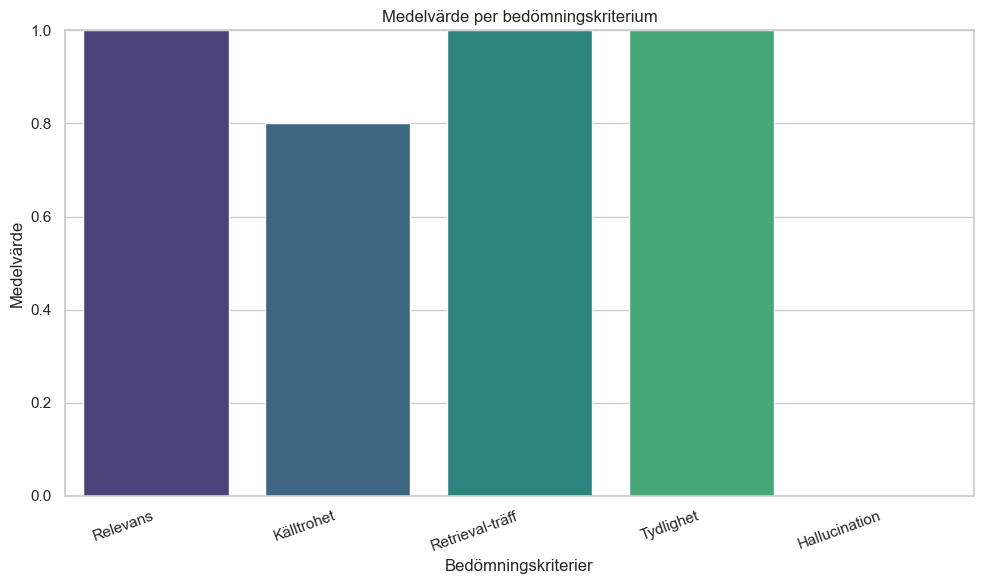

In [18]:
# Rita grafen
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=criteria_means,
    x="bedömningskriterium",
    y="medelvärde",
    hue="bedömningskriterium",
    dodge=False,
    palette="viridis",
    legend=False
)

ax.set_title("Medelvärde per bedömningskriterium")
ax.set_xlabel("Bedömningskriterier")
ax.set_ylabel("Medelvärde")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [19]:
# Sparar resultatet
scored_df.to_csv("chatbot_evaluering_detaljer.csv", index=False, encoding="utf-8-sig")
summary_df.to_csv("chatbot_evaluering_sammanfattning.csv", index=False, encoding="utf-8-sig")

print("Filer sparade:")
print("- chatbot_evaluering_detaljer.csv")
print("- chatbot_evaluering_sammanfattning.csv")

Filer sparade:
- chatbot_evaluering_detaljer.csv
- chatbot_evaluering_sammanfattning.csv
